In [1]:
from google.colab import drive
drive.mount('/content/drive')

# 코랩 konlpy 실행
!curl -s https://raw.githubusercontent.com/teddylee777/machine-learning/master/99-Misc/01-Colab/mecab-colab.sh | bash

# Mecab 설치 후 Google Drive에 복사
!cp -r /usr/local/lib/mecab /content/drive/MyDrive/mecab
!cp -r /usr/local/etc/mecabrc /content/drive/MyDrive/mecab

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--2026-06-01 07:29:00--  https://www.dropbox.com/s/9xls0tgtf3edgns/mecab-0.996-ko-0.9.2.tar.gz?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.70.18, 2620:100:6026:18::a27d:4612
Connecting to www.dropbox.com (www.dropbox.com)|162.125.70.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/g8l6dlu5a3ebovcdymluq/mecab-0.996-ko-0.9.2.tar.gz?rlkey=xlooryouhr1l2ufqbt93ohfvy&dl=1 [following]
--2026-06-01 07:29:01--  https://www.dropbox.com/scl/fi/g8l6dlu5a3ebovcdymluq/mecab-0.996-ko-0.9.2.tar.gz?rlkey=xlooryouhr1l2ufqbt93ohfvy&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc867b32efe8b52642a2d2a06ada.dl.dropboxusercontent.com/cd/0/inline/DBhdb5frmtup8bmjGN6yKS2yWQ-3FYglql1x_q4AuGmZcs5J-wCgkpCAAEMS2tHU4jryRqoA1Y6e-sKj

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
from konlpy.tag import Okt
from collections import Counter
import re

In [6]:
import pandas as pd
df2 = pd.read_pickle('/content/drive/MyDrive/DX PROJ./임베딩/이걸로/cluster2_sub_topics_5개로.pkl')

In [5]:
df0 = pd.read_pickle('/content/drive/MyDrive/DX PROJ./임베딩/이걸로/cluster0_sub_topics_4개로.pkl')

In [7]:
df0

,제목,본문,token,embedding,cluster_k3,joined_tokens,tokens,sub_cluster
0,NaN,가족들 그엘베 타는거 고역이겠다 어떻게 사냐,"[가족, 엘베, 타다, 고역, 겠다, 어떻다, 사다]","[-0.5792470574378967, -0.3509799838066101, -0....",0,가족 엘베 타다 고역 겠다 어떻다 사다,가족 엘베 타다 고역 겠다 어떻다 사다,3
1,NaN,엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요,"[엘베, 층간소음, 다투다, 벽, 세탁기, 돌리다]","[-0.6158533692359924, -0.061289992183446884, 0...",0,엘베 층간소음 다투다 벽 세탁기 돌리다,엘베 층간소음 다투다 벽 세탁기 돌리다,0
2,NaN,아파트 층간소음 불만충들 나무아파트에서 강제로 살게 하기 법을 만듭시다,"[아파트, 층간소음, 불만, 충, 나무, 아파트, 강제, 살, 법, 만듭시]","[-0.5051539540290833, -0.6635602712631226, 0.2...",0,아파트 층간소음 불만 충 나무 아파트 강제 살 하다 법 만듭시,아파트 층간소음 불만 충 나무 아파트 강제 살 법 만듭시,2
3,NaN,윗집 남자 피해자 죽임당하셔구냐 불쌍해요 층간소음 윗층 할머니 새벽 시에 믹서기 돌...,"[집, 남자, 피해자, 죽이다, 당하다, 구, 불쌍하다, 층간소음, 층, 할머니, ...","[-0.6405828595161438, -0.6092670559883118, 0.2...",0,집 남자 피해자 죽이다 당하다 구 불쌍하다 층간소음 층 할머니 새벽 시 믹서기 돌리...,집 남자 피해자 죽이다 당하다 구 불쌍하다 층간소음 층 할머니 새벽 시 믹서기 돌리...,0
4,NaN,아파트란게 윗층 소음만 들리는게 아니더라 윗층 올라가보니 애기들도 없는데 아래서는 ...,"[아파트, 란, 층, 소음, 들리다, 아니다, 층, 올라가다, 애기, 없다, 아래,...","[-0.13890789449214935, -0.33729928731918335, -...",0,아파트 란 층 소음 들리다 아니다 층 올라가다 보다 애기 없다 아래 서다 아기 뛰어다니다,아파트 란 층 소음 들리다 아니다 층 올라가다 애기 없다 아래 서다 아기 뛰어다니다,3
...,...,...,...,...,...,...,...,...
23129,화장실충,진짜 왜 안방 화장실은 안 쓰고 꼭 거실 화장실만 쓸까요 청소하기 귀찮아서 하나는 ...,"[진짜, 왜, 안방, 화장실, 안, 쓰다, 꼭, 거실, 화장실, 쓸다, 요, 청소,...","[-0.3919851779937744, -0.4484711289405823, -0....",0,진짜 왜 안방 화장실 안 쓰다 꼭 거실 화장실 쓸다 요 청소 하다 귀찮다 하나 방치...,진짜 왜 안방 화장실 안 쓰다 꼭 거실 화장실 쓸다 요 청소 귀찮다 하나 방치 중인...,0
23130,13층 미친 것들,층간소음충들은 왜 잠도 안 자고 밖에 나가지도 않고 맨날 집구석에서 지랄들일까요 5...,"[층간소음, 충, 왜, 잠도, 안, 자고, 나가다, 않다, 집, 구석, 지랄, 들이...","[-0.4979175627231598, -0.26332905888557434, 0....",0,층간소음 충 왜 잠도 안 자고 나가다 않다 집 구석 지랄 들이다 요 아이 뛰다 동안...,층간소음 충 왜 잠도 안 자고 나가다 않다 집 구석 지랄 들이다 요 아이 뛰다 동안...,0
23131,아니 발 모가지 분질러야되나요,매일 이 늦은 시간에 워킹패드하는지 층간소음층간소음 웈웈웈웅 하 윗집인지 웟윗집인지...,"[매일, 늦다, 시간, 워킹, 패드, 층간소음, 층간소음, 웈웈웈웅, 집, 웠윗집,...","[-0.42004770040512085, -0.21702244877815247, -...",0,매일 늦다 시간 워킹 패드 하다 층간소음 층간소음 웈웈웈웅 집 웠윗집 집 지옥 요 지옥,매일 늦다 시간 워킹 패드 층간소음 층간소음 웈웈웈웅 집 웠윗집 집 지옥 요 지옥,0
23132,이것들은왜 외출도안하나요,주말인데도 외출하는꼴을못보네 아오 집에서 시끄러우면 자주나가기라도해라,"[주말, 외출, 꼴다, 집, 시끄럽다, 자주, 나가다, 도해]","[-0.7162784934043884, -0.28542742133140564, 0....",0,주말 외출 하다 꼴다 보다 집 시끄럽다 자주 나가다 도해,주말 외출 꼴다 집 시끄럽다 자주 나가다 도해,1


In [8]:
df2

,제목,본문,token,embedding,cluster_k3,joined_tokens,tokens,sub_cluster
0,NaN,서대구역 구역 이라고 들었는데 단지인지 정확히는 잘모르겠지만 부실공사에 제값보다 고...,"[서대구역, 구역, 들다, 단지, 정확하다, 모르다, 부실, 공사, 값, 평가, 아...","[-0.14360012114048004, -0.005446251481771469, ...",2,서대구역 구역 들다 단지 정확하다 모르다 부실 공사 값 평가 되다 아파트 맞다,서대구역 구역 들다 단지 정확하다 모르다 부실 공사 값 평가 아파트 맞다,0
1,NaN,정신병자를 이웃으로만난게 불운이였다 조현병같은데 둔거야,"[정신병, 이웃, 난, 불다, 조현병, 같다, 두다]","[-0.8485231399536133, -0.4335775673389435, 0.0...",2,정신병 이웃 난 불다 조현병 같다 두다,정신병 이웃 난 불다 조현병 같다 두다,1
2,NaN,인간이길 포기한 숨쉬며 꿈틀꿈틀 움직이는 물체는 폐기처분 합시다 자꾸 이런저런 이유...,"[인간, 이기다, 포기, 숨쉬다, 움직이다, 물체, 폐기, 처분, 자꾸, 이유, 비...","[-0.16455712914466858, -0.4579088091850281, 0....",2,인간 이기다 포기 숨쉬다 움직이다 물체 폐기 처분 하다 자꾸 이유 보다 비극 사건 ...,인간 이기다 포기 숨쉬다 움직이다 물체 폐기 처분 자꾸 이유 비극 사건 남무 세상 ...,1
3,NaN,꼴통이아래집에살고있으니 노답이네 조현병은불치병이라 완치안돼 정신병자라 더잔인함 절대...,"[꼴통, 아래, 집, 살다, 노답, 조현병, 불치, 병, 완치, 돼다, 정신병, 자...","[-0.9262545704841614, -0.2466546893119812, 0.2...",2,꼴통 아래 집 살다 노답 조현병 불치 병 완치 돼다 정신병 자라 잔인함 절대로 근처...,꼴통 아래 집 살다 노답 조현병 불치 병 완치 돼다 정신병 자라 잔인함 절대로 근처...,1
4,NaN,저런거는 섬에 가두고 먹을꺼주지말고 던저놓자 돌아가신분이 무슨 죄냐 안타깝습니다 대...,"[저러다, 섬, 가두다, 먹다, 던저, 놓다, 돌아가다, 신분, 무슨, 죄, 안타깝...","[0.08430330455303192, -0.5858102440834045, 0.0...",2,저러다 섬 가두다 먹다 던저 놓다 돌아가다 신분 무슨 죄 안타깝다 살 있다 독하다 독해,저러다 섬 가두다 먹다 던저 놓다 돌아가다 신분 무슨 죄 안타깝다 살 독하다 독해,1
...,...,...,...,...,...,...,...,...
20426,층간소음때문에 상담 받는 분 계세요?,효과 있나요,[효과],"[-0.14729392528533936, -0.6821265816688538, -0...",2,효과 있다,효과,0
20427,안산변기막힘 급한데 어디서 하수구막힘 뚫는업체 찾나요?,급한부분이라 질문 하나 드려요 안산변기막힘 급한데 어디서 하수구막힘 뚫는업체 찾나요...,"[급하다, 부분, 질문, 하나, 드리다, 안산, 변기, 막히다, 급하다, 하수, 구...","[-0.24007713794708252, -0.20653827488422394, -...",2,급하다 부분 질문 하나 드리다 안산 변기 막히다 급하다 하수 구 막히다 뚫다 업체 ...,급하다 부분 질문 하나 드리다 안산 변기 막히다 급하다 하수 구 막히다 뚫다 업체 ...,0
20428,ㅋㅋㅋ,역할 제대로 하나봐요 저주파 틀어주니 좋다고 난리 났네요 그렇데 힘들게 발 찍고 난...,"[역할, 제대로, 하나, 주파, 틀어주다, 좋다, 난리, 나다, 그렇다, 힘들다, ...","[0.027184050530195236, -0.15931132435798645, 0...",2,역할 제대로 하나 보다 주파 틀어주다 좋다 난리 나다 그렇다 힘들다 발 찍다 난리치...,역할 제대로 하나 주파 틀어주다 좋다 난리 나다 그렇다 힘들다 발 찍다 난리치다 힘...,2
20429,아이폰에 소리랑 발망치가 안담겨요… 뭘로하세요?,동영상을 찍어도 소리가 안들리고 그러네요 귀로는 진짜큰데,"[동영상, 찍다, 소리, 들리다, 그렇다, 귀로, 진짜, 크다]","[0.048345260322093964, 0.21559062600135803, -0...",2,동영상 찍다 소리 들리다 그렇다 귀로 진짜 크다,동영상 찍다 소리 들리다 그렇다 귀로 진짜 크다,2


In [10]:
df0

,제목,본문,token,embedding,cluster_k3,joined_tokens,tokens,sub_cluster
0,NaN,가족들 그엘베 타는거 고역이겠다 어떻게 사냐,"[가족, 엘베, 타다, 고역, 겠다, 어떻다, 사다]","[-0.5792470574378967, -0.3509799838066101, -0....",0,가족 엘베 타다 고역 겠다 어떻다 사다,가족 엘베 타다 고역 겠다 어떻다 사다,3
1,NaN,엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요,"[엘베, 층간소음, 다투다, 벽, 세탁기, 돌리다]","[-0.6158533692359924, -0.061289992183446884, 0...",0,엘베 층간소음 다투다 벽 세탁기 돌리다,엘베 층간소음 다투다 벽 세탁기 돌리다,0
2,NaN,아파트 층간소음 불만충들 나무아파트에서 강제로 살게 하기 법을 만듭시다,"[아파트, 층간소음, 불만, 충, 나무, 아파트, 강제, 살, 법, 만듭시]","[-0.5051539540290833, -0.6635602712631226, 0.2...",0,아파트 층간소음 불만 충 나무 아파트 강제 살 하다 법 만듭시,아파트 층간소음 불만 충 나무 아파트 강제 살 법 만듭시,2
3,NaN,윗집 남자 피해자 죽임당하셔구냐 불쌍해요 층간소음 윗층 할머니 새벽 시에 믹서기 돌...,"[집, 남자, 피해자, 죽이다, 당하다, 구, 불쌍하다, 층간소음, 층, 할머니, ...","[-0.6405828595161438, -0.6092670559883118, 0.2...",0,집 남자 피해자 죽이다 당하다 구 불쌍하다 층간소음 층 할머니 새벽 시 믹서기 돌리...,집 남자 피해자 죽이다 당하다 구 불쌍하다 층간소음 층 할머니 새벽 시 믹서기 돌리...,0
4,NaN,아파트란게 윗층 소음만 들리는게 아니더라 윗층 올라가보니 애기들도 없는데 아래서는 ...,"[아파트, 란, 층, 소음, 들리다, 아니다, 층, 올라가다, 애기, 없다, 아래,...","[-0.13890789449214935, -0.33729928731918335, -...",0,아파트 란 층 소음 들리다 아니다 층 올라가다 보다 애기 없다 아래 서다 아기 뛰어다니다,아파트 란 층 소음 들리다 아니다 층 올라가다 애기 없다 아래 서다 아기 뛰어다니다,3
...,...,...,...,...,...,...,...,...
23129,화장실충,진짜 왜 안방 화장실은 안 쓰고 꼭 거실 화장실만 쓸까요 청소하기 귀찮아서 하나는 ...,"[진짜, 왜, 안방, 화장실, 안, 쓰다, 꼭, 거실, 화장실, 쓸다, 요, 청소,...","[-0.3919851779937744, -0.4484711289405823, -0....",0,진짜 왜 안방 화장실 안 쓰다 꼭 거실 화장실 쓸다 요 청소 하다 귀찮다 하나 방치...,진짜 왜 안방 화장실 안 쓰다 꼭 거실 화장실 쓸다 요 청소 귀찮다 하나 방치 중인...,0
23130,13층 미친 것들,층간소음충들은 왜 잠도 안 자고 밖에 나가지도 않고 맨날 집구석에서 지랄들일까요 5...,"[층간소음, 충, 왜, 잠도, 안, 자고, 나가다, 않다, 집, 구석, 지랄, 들이...","[-0.4979175627231598, -0.26332905888557434, 0....",0,층간소음 충 왜 잠도 안 자고 나가다 않다 집 구석 지랄 들이다 요 아이 뛰다 동안...,층간소음 충 왜 잠도 안 자고 나가다 않다 집 구석 지랄 들이다 요 아이 뛰다 동안...,0
23131,아니 발 모가지 분질러야되나요,매일 이 늦은 시간에 워킹패드하는지 층간소음층간소음 웈웈웈웅 하 윗집인지 웟윗집인지...,"[매일, 늦다, 시간, 워킹, 패드, 층간소음, 층간소음, 웈웈웈웅, 집, 웠윗집,...","[-0.42004770040512085, -0.21702244877815247, -...",0,매일 늦다 시간 워킹 패드 하다 층간소음 층간소음 웈웈웈웅 집 웠윗집 집 지옥 요 지옥,매일 늦다 시간 워킹 패드 층간소음 층간소음 웈웈웈웅 집 웠윗집 집 지옥 요 지옥,0
23132,이것들은왜 외출도안하나요,주말인데도 외출하는꼴을못보네 아오 집에서 시끄러우면 자주나가기라도해라,"[주말, 외출, 꼴다, 집, 시끄럽다, 자주, 나가다, 도해]","[-0.7162784934043884, -0.28542742133140564, 0....",0,주말 외출 하다 꼴다 보다 집 시끄럽다 자주 나가다 도해,주말 외출 꼴다 집 시끄럽다 자주 나가다 도해,1


In [11]:
import pandas as pd

# 위·아래로 이어 붙이기
result = pd.concat([df0, df2], axis=0)

# 기존 인덱스를 무시하고 0, 1, 2...로 새로 지정하고 싶다면 ignore_index=True 추가
result = pd.concat([df0, df2], axis=0, ignore_index=True)

In [12]:
result

,제목,본문,token,embedding,cluster_k3,joined_tokens,tokens,sub_cluster
0,NaN,가족들 그엘베 타는거 고역이겠다 어떻게 사냐,"[가족, 엘베, 타다, 고역, 겠다, 어떻다, 사다]","[-0.5792470574378967, -0.3509799838066101, -0....",0,가족 엘베 타다 고역 겠다 어떻다 사다,가족 엘베 타다 고역 겠다 어떻다 사다,3
1,NaN,엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요,"[엘베, 층간소음, 다투다, 벽, 세탁기, 돌리다]","[-0.6158533692359924, -0.061289992183446884, 0...",0,엘베 층간소음 다투다 벽 세탁기 돌리다,엘베 층간소음 다투다 벽 세탁기 돌리다,0
2,NaN,아파트 층간소음 불만충들 나무아파트에서 강제로 살게 하기 법을 만듭시다,"[아파트, 층간소음, 불만, 충, 나무, 아파트, 강제, 살, 법, 만듭시]","[-0.5051539540290833, -0.6635602712631226, 0.2...",0,아파트 층간소음 불만 충 나무 아파트 강제 살 하다 법 만듭시,아파트 층간소음 불만 충 나무 아파트 강제 살 법 만듭시,2
3,NaN,윗집 남자 피해자 죽임당하셔구냐 불쌍해요 층간소음 윗층 할머니 새벽 시에 믹서기 돌...,"[집, 남자, 피해자, 죽이다, 당하다, 구, 불쌍하다, 층간소음, 층, 할머니, ...","[-0.6405828595161438, -0.6092670559883118, 0.2...",0,집 남자 피해자 죽이다 당하다 구 불쌍하다 층간소음 층 할머니 새벽 시 믹서기 돌리...,집 남자 피해자 죽이다 당하다 구 불쌍하다 층간소음 층 할머니 새벽 시 믹서기 돌리...,0
4,NaN,아파트란게 윗층 소음만 들리는게 아니더라 윗층 올라가보니 애기들도 없는데 아래서는 ...,"[아파트, 란, 층, 소음, 들리다, 아니다, 층, 올라가다, 애기, 없다, 아래,...","[-0.13890789449214935, -0.33729928731918335, -...",0,아파트 란 층 소음 들리다 아니다 층 올라가다 보다 애기 없다 아래 서다 아기 뛰어다니다,아파트 란 층 소음 들리다 아니다 층 올라가다 애기 없다 아래 서다 아기 뛰어다니다,3
...,...,...,...,...,...,...,...,...
43560,층간소음때문에 상담 받는 분 계세요?,효과 있나요,[효과],"[-0.14729392528533936, -0.6821265816688538, -0...",2,효과 있다,효과,0
43561,안산변기막힘 급한데 어디서 하수구막힘 뚫는업체 찾나요?,급한부분이라 질문 하나 드려요 안산변기막힘 급한데 어디서 하수구막힘 뚫는업체 찾나요...,"[급하다, 부분, 질문, 하나, 드리다, 안산, 변기, 막히다, 급하다, 하수, 구...","[-0.24007713794708252, -0.20653827488422394, -...",2,급하다 부분 질문 하나 드리다 안산 변기 막히다 급하다 하수 구 막히다 뚫다 업체 ...,급하다 부분 질문 하나 드리다 안산 변기 막히다 급하다 하수 구 막히다 뚫다 업체 ...,0
43562,ㅋㅋㅋ,역할 제대로 하나봐요 저주파 틀어주니 좋다고 난리 났네요 그렇데 힘들게 발 찍고 난...,"[역할, 제대로, 하나, 주파, 틀어주다, 좋다, 난리, 나다, 그렇다, 힘들다, ...","[0.027184050530195236, -0.15931132435798645, 0...",2,역할 제대로 하나 보다 주파 틀어주다 좋다 난리 나다 그렇다 힘들다 발 찍다 난리치...,역할 제대로 하나 주파 틀어주다 좋다 난리 나다 그렇다 힘들다 발 찍다 난리치다 힘...,2
43563,아이폰에 소리랑 발망치가 안담겨요… 뭘로하세요?,동영상을 찍어도 소리가 안들리고 그러네요 귀로는 진짜큰데,"[동영상, 찍다, 소리, 들리다, 그렇다, 귀로, 진짜, 크다]","[0.048345260322093964, 0.21559062600135803, -0...",2,동영상 찍다 소리 들리다 그렇다 귀로 진짜 크다,동영상 찍다 소리 들리다 그렇다 귀로 진짜 크다,2


In [14]:
result.to_csv('토픽까지 데이터 합친거.csv')

In [15]:
import pandas as pd

# result가 리스트/딕셔너리인 경우
df = pd.DataFrame(result)
df.to_csv('output.csv', index=False, encoding='utf-8-sig')

현재 사용할 디바이스: CPU


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: Copycats/koelectra-base-v3-generalized-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
electra.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


통합 데이터 감성 분석 중:   0%|          | 0/1362 [00:00<?, ?it/s]

🎉 감성 분석 완료!



=================== 🎯 기회 영역 분석 기초 테이블 ===================
  topic_name  total_count  neg_count    neg_rate
0  Topic_2_4          213        213  100.000000
1  Topic_0_0         8178       6507   79.567131
2  Topic_0_3         4318       3317   76.817971
3  Topic_0_1         6553       4376   66.778575
4  Topic_0_2         4085       2645   64.749082
5  Topic_2_1         5787       3683   63.642647
6  Topic_2_0         5129       3069   59.836225
7  Topic_2_2         3807       2073   54.452325
8  Topic_2_3         5495       2176   39.599636


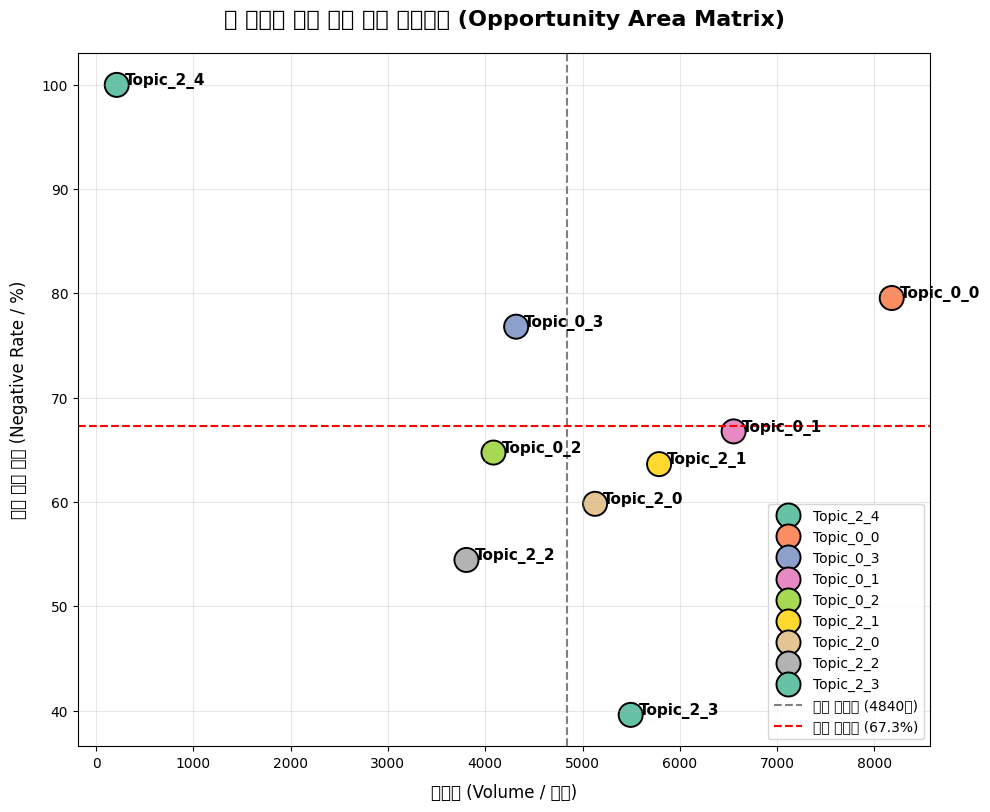

💾 매트릭스 시각화 이미지가 구글 드라이브에 저장되었습니다!


In [18]:
import pandas as pd
import torch
from transformers import pipeline
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# [준비] 데이터 병합 및 인덱스 완전히 초기화
# ==========================================
# 혹시 모를 인덱스 충돌을 방지하기 위해 한 번 더 확실하게 reset 해줍니다.
result = pd.concat([df0, df2], axis=0, ignore_index=True)
result = result.reset_index(drop=True)

# ==========================================
# [Step 1] 통합 데이터 감성 분석 실행
# ==========================================
device = 0 if torch.cuda.is_available() else -1
print(f"현재 사용할 디바이스: {'GPU (cuda)' if device == 0 else 'CPU'}")

classifier = pipeline(
    "text-classification",
    model="Copycats/koelectra-base-v3-generalized-sentiment-analysis",
    device=device
)

# 숫자가 섞여 있어도 에러 안 나게 문자열 변환
texts = result['본문'].fillna("").astype(str).tolist()
sentiment_results = []
batch_size = 32

for i in tqdm(range(0, len(texts), batch_size), desc="통합 데이터 감성 분석 중"):
    batch_texts = texts[i:i+batch_size]
    # Fix: Add max_length parameter to truncate input sequences to 512 tokens
    batch_results = classifier(batch_texts, truncation=True, max_length=512)
    sentiment_results.extend(batch_results)

label_map = {'0': 'NEGATIVE', '1': 'POSITIVE', 'LABEL_0': 'NEGATIVE', 'LABEL_1': 'POSITIVE'}
result['sentiment_label'] = [label_map.get(res['label'], res['label']) for res in sentiment_results]
result['sentiment_score'] = [res['score'] for res in sentiment_results]

print("🎉 감성 분석 완료!")

# ==========================================
# [Step 2] 기회 영역 분석용 통계 테이블 집계
# ==========================================
# 유니크한 토픽명 생성
result['topic_name'] = 'Topic_' + result['cluster_k3'].astype(str) + '_' + result['sub_cluster'].astype(str)

total_counts = result.groupby('topic_name').size().reset_index(name='total_count')
neg_counts = result[result['sentiment_label'] == 'NEGATIVE'].groupby('topic_name').size().reset_index(name='neg_count')

opportunity_df = pd.merge(total_counts, neg_counts, on='topic_name', how='left').fillna(0)
opportunity_df['neg_rate'] = (opportunity_df['neg_count'] / opportunity_df['total_count']) * 100

# 정렬 후 인덱스를 0부터 순서대로 완벽히 리셋 (시각화 에러 방지 핵심)
opportunity_df = opportunity_df.sort_values(by=['neg_rate', 'total_count'], ascending=False).reset_index(drop=True)

print("\n=================== 🎯 기회 영역 분석 기초 테이블 ===================")
print(opportunity_df)

# ==========================================
# [Step 3] PPT 맞춤형 기회 영역 매트릭스 시각화
# ==========================================
plt.rc('font', family='NanumBarunGothic')
fig, ax = plt.subplots(figsize=(11, 9))

sns.scatterplot(
    data=opportunity_df,
    x='total_count',
    y='neg_rate',
    s=300,
    hue='topic_name',
    palette='Set2',
    edgecolor='black',
    ax=ax
)

# 가이드 라인 (평균선)
mean_count = opportunity_df['total_count'].mean()
mean_neg = opportunity_df['neg_rate'].mean()
plt.axvline(x=mean_count, color='gray', linestyle='--', linewidth=1.5, label=f'평균 언급량 ({int(mean_count)}건)')
plt.axhline(y=mean_neg, color='red', linestyle='--', linewidth=1.5, label=f'평균 부정률 ({mean_neg:.1f}%)')

# 🔥 핵심 수정: .iloc[i] 방식을 사용하여 인덱스 에러를 원천 차단합니다.
max_x_margin = opportunity_df['total_count'].max() * 0.01
for i in range(len(opportunity_df)):
    row = opportunity_df.iloc[i]
    plt.text(
        row['total_count'] + max_x_margin,
        row['neg_rate'],
        row['topic_name'],
        fontsize=11,
        weight='bold'
    )

plt.title('🎯 서비스 개선 기회 영역 매트릭스 (Opportunity Area Matrix)', fontsize=16, pad=20, weight='bold')
plt.xlabel('언급량 (Volume / 건수)', fontsize=12, labelpad=10)
plt.ylabel('부정 여론 비율 (Negative Rate / %)', fontsize=12, labelpad=10)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')

# 저장 후 출력
plt.savefig('/content/drive/MyDrive/opportunity_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 매트릭스 시각화 이미지가 구글 드라이브에 저장되었습니다!")

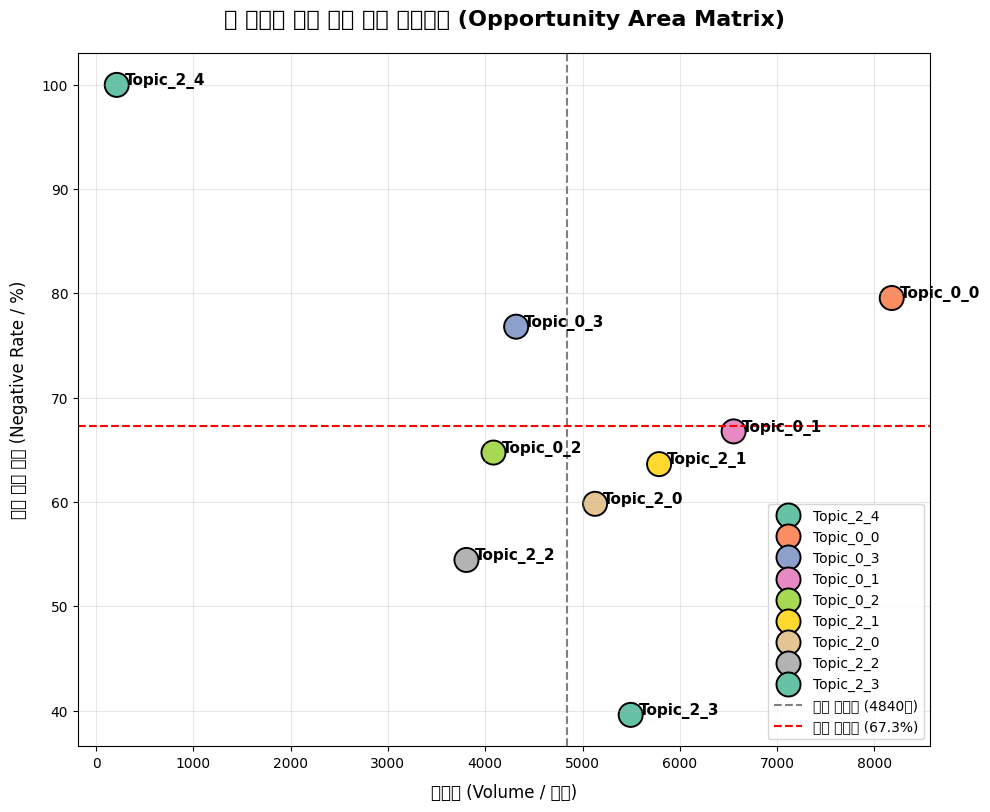

In [19]:
plt.rc('font', family='NanumBarunGothic')
fig, ax = plt.subplots(figsize=(11, 9))

sns.scatterplot(
    data=opportunity_df,
    x='total_count',
    y='neg_rate',
    s=300,
    hue='topic_name',
    palette='Set2',
    edgecolor='black',
    ax=ax
)

# 가이드 라인 (평균선)
mean_count = opportunity_df['total_count'].mean()
mean_neg = opportunity_df['neg_rate'].mean()
plt.axvline(x=mean_count, color='gray', linestyle='--', linewidth=1.5, label=f'평균 언급량 ({int(mean_count)}건)')
plt.axhline(y=mean_neg, color='red', linestyle='--', linewidth=1.5, label=f'평균 부정률 ({mean_neg:.1f}%)')

# 🔥 핵심 수정: .iloc[i] 방식을 사용하여 인덱스 에러를 원천 차단합니다.
max_x_margin = opportunity_df['total_count'].max() * 0.01
for i in range(len(opportunity_df)):
    row = opportunity_df.iloc[i]
    plt.text(
        row['total_count'] + max_x_margin,
        row['neg_rate'],
        row['topic_name'],
        fontsize=11,
        weight='bold'
    )

plt.title('🎯 서비스 개선 기회 영역 매트릭스 (Opportunity Area Matrix)', fontsize=16, pad=20, weight='bold')
plt.xlabel('언급량 (Volume / 건수)', fontsize=12, labelpad=10)
plt.ylabel('부정 여론 비율 (Negative Rate / %)', fontsize=12, labelpad=10)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')


=== 📊 Cluster 0 하위 토픽별 오퍼튜니티 데이터 ===
   sub_cluster  total_count  raw_satisfaction  relative_importance  \
0            0         8178          0.204329             1.000000   
1            1         6553          0.332214             0.602981   
2            2         4085          0.352509             0.000000   
3            3         4318          0.231820             0.056926   

   relative_satisfaction  
0               0.000000  
1               0.863039  
2               1.000000  
3               0.185528  


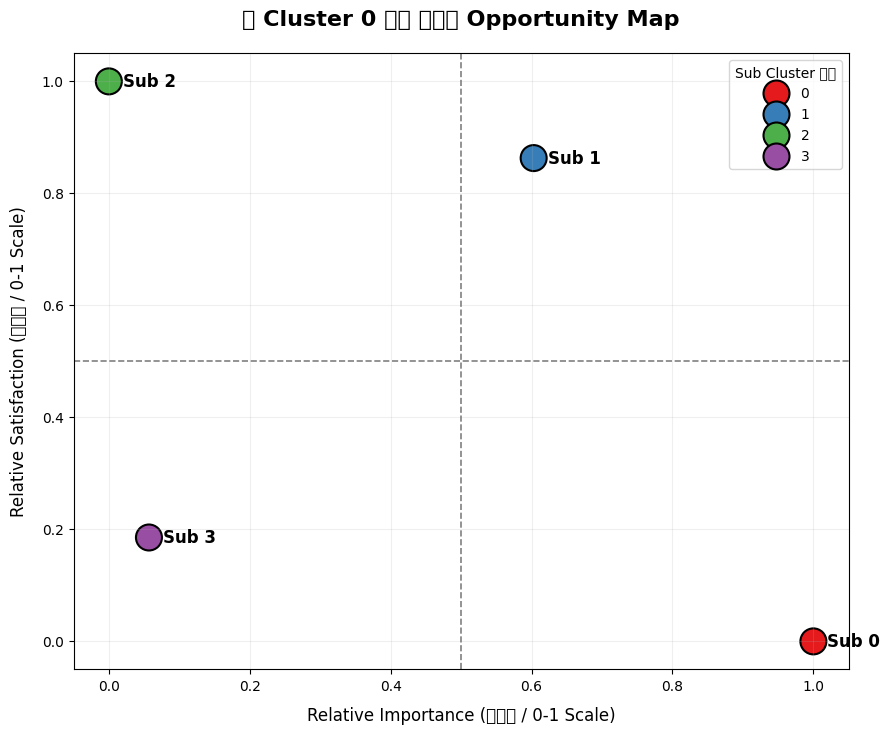

💾 Cluster 0의 기회지도가 'opportunity_map_cluster0.png'로 저장되었습니다!


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Cluster 0 데이터 필터링 및 통계 집계
# ==========================================
# Cluster 0 데이터만 카피
df_c0 = result[result['cluster_k3'] == 0].copy()

# 하위 토픽(Sub-cluster)별로 전체 언급량과 긍정(POSITIVE) 건수 집계
stats_c0 = df_c0.groupby('sub_cluster').agg(
    total_count=('sentiment_label', 'count'),
    positive_count=('sentiment_label', lambda x: (x == 'POSITIVE').sum())
).reset_index()

# 원본 만족도(긍정 비율) 계산
stats_c0['raw_satisfaction'] = stats_c0['positive_count'] / stats_c0['total_count']

# ==========================================
# 2. 0 ~ 1 Scale로 정규화 (Relative Scaling)
# ==========================================
# 1e-9는 혹시 모를 분모 0 에러 방지용입니다.
min_vol, max_vol = stats_c0['total_count'].min(), stats_c0['total_count'].max()
min_sat, max_sat = stats_c0['raw_satisfaction'].min(), stats_c0['raw_satisfaction'].max()

# X축: Relative Importance (Min-Max Scaling)
stats_c0['relative_importance'] = (stats_c0['total_count'] - min_vol) / (max_vol - min_vol + 1e-9)

# Y축: Relative Satisfaction (Min-Max Scaling)
stats_c0['relative_satisfaction'] = (stats_c0['raw_satisfaction'] - min_sat) / (max_sat - min_sat + 1e-9)

print("=== 📊 Cluster 0 하위 토픽별 오퍼튜니티 데이터 ===")
print(stats_c0[['sub_cluster', 'total_count', 'raw_satisfaction', 'relative_importance', 'relative_satisfaction']])


# ==========================================
# 3. Cluster 0 오퍼튜니티 맵 시각화 (0~1 Scale)
# ==========================================
plt.rc('font', family='NanumBarunGothic')
plt.figure(figsize=(10, 8))

# 스캐터 플롯 그리기
sns.scatterplot(
    data=stats_c0,
    x='relative_importance',
    y='relative_satisfaction',
    s=350,                  # 마커 크기 키움
    hue='sub_cluster',
    palette='Set1',         # 하위 토픽별 구분이 잘 되는 색상
    edgecolor='black',
    linewidth=1.5
)

# 0~1 스케일 매트릭스의 정중앙 가이드라인 (0.5 선) 추가
plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.2)
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.2)

# 각 점 옆에 Sub-cluster 번호 라벨링
for i in range(len(stats_c0)):
    row = stats_c0.iloc[i]
    plt.text(
        row['relative_importance'] + 0.02, # 글자가 점과 겹치지 않게 가로 마진 조정
        row['relative_satisfaction'] - 0.01,
        f"Sub {int(row['sub_cluster'])}",
        fontsize=12, weight='bold'
    )

# 축 범위 설정 (0~1 스케일이므로 넉넉하게 마진 제공)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

# 타이틀 및 서식
plt.title('🎯 Cluster 0 하위 토픽별 Opportunity Map', fontsize=16, pad=20, weight='bold')
plt.xlabel('Relative Importance (중요도 / 0-1 Scale)', fontsize=12, labelpad=10)
plt.ylabel('Relative Satisfaction (만족도 / 0-1 Scale)', fontsize=12, labelpad=10)
plt.grid(True, alpha=0.2)
plt.legend(title='Sub Cluster 번호', loc='upper right')

# 구글 드라이브에 이미지 파일로 저장
plt.savefig('/content/drive/MyDrive/opportunity_map_cluster0.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Cluster 0의 기회지도가 'opportunity_map_cluster0.png'로 저장되었습니다!")

In [21]:
df.to_pickle('기회영역-cluster0.pkl')opportunity_df

In [23]:
opportunity_df.to_pickle('기회영역-cluster00000.pkl')

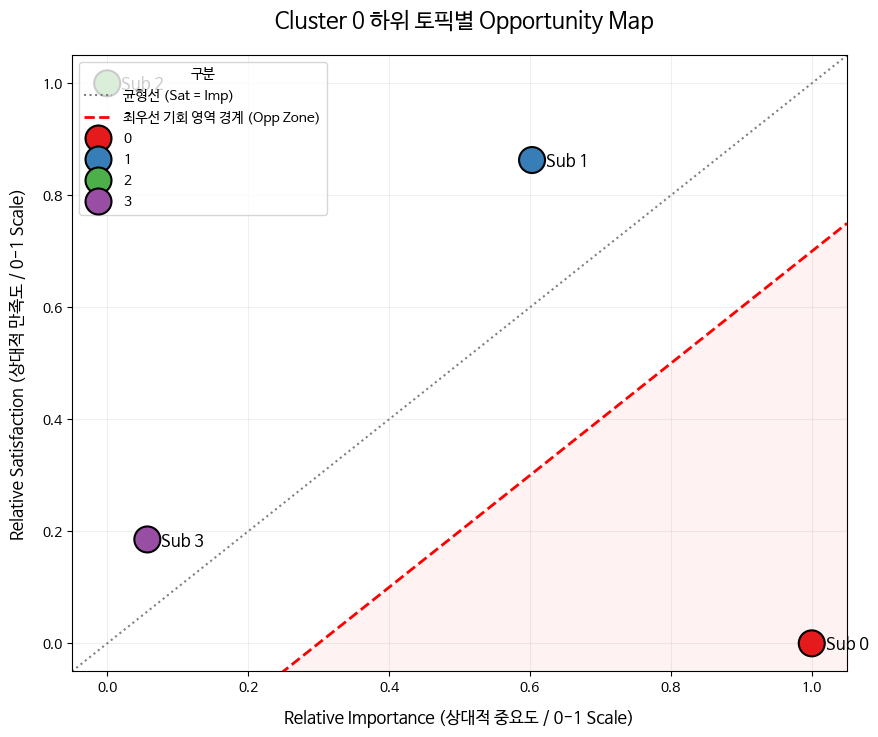

In [24]:
# 1. 한글 폰트 미설치 오류 해결을 위해 시스템 다운로드 및 matplotlib 등록
!apt-get -qq -y install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 나눔바른고딕 폰트 추가 및 설정
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# ==========================================
# 2. 데이터 집계 및 0~1 스케일 정규화 (이전 동일)
# ==========================================
df_c0 = result[result['cluster_k3'] == 0].copy()

stats_c0 = df_c0.groupby('sub_cluster').agg(
    total_count=('sentiment_label', 'count'),
    positive_count=('sentiment_label', lambda x: (x == 'POSITIVE').sum())
).reset_index()

stats_c0['raw_satisfaction'] = stats_c0['positive_count'] / stats_c0['total_count']

min_vol, max_vol = stats_c0['total_count'].min(), stats_c0['total_count'].max()
min_sat, max_sat = stats_c0['raw_satisfaction'].min(), stats_c0['raw_satisfaction'].max()

stats_c0['relative_importance'] = (stats_c0['total_count'] - min_vol) / (max_vol - min_vol + 1e-9)
stats_c0['relative_satisfaction'] = (stats_c0['raw_satisfaction'] - min_sat) / (max_sat - min_sat + 1e-9)


# ==========================================
# 3. 오퍼튜니티 맵 시각화 (대각선 가이드라인 추가)
# ==========================================
fig, ax = plt.subplots(figsize=(10, 8))

# 배경에 사선 가이드라인(대각선) 그리기
# 중요도(X)는 높은데 만족도(Y)가 낮은 우하단 영역을 가르는 기준선입니다.
x_vals = np.linspace(-0.05, 1.05, 100)
# y = x 선 (만족도와 중요도가 비례하는 균형선)
plt.plot(x_vals, x_vals, color='gray', linestyle=':', linewidth=1.5, label='균형선 (Sat = Imp)')
# 기회 영역 경계 대각선 (예: 만족도가 중요도보다 0.3 이상 뒤처지는 지점)
plt.plot(x_vals, x_vals - 0.3, color='red', linestyle='--', linewidth=2, label='최우선 기회 영역 경계 (Opp Zone)')

# 기회 영역(우하단) 시각적 강조를 위한 옅은 붉은색 음영 처리
plt.fill_between(x_vals, -0.05, x_vals - 0.3, color='red', alpha=0.05)

# 데이터 점 찍기
sns.scatterplot(
    data=stats_c0,
    x='relative_importance',
    y='relative_satisfaction',
    s=350,
    hue='sub_cluster',
    palette='Set1',
    edgecolor='black',
    linewidth=1.5,
    zorder=3  # 선들보다 위에 점이 오도록 설정
)

# 각 점에 하위 토픽 라벨링
for i in range(len(stats_c0)):
    row = stats_c0.iloc[i]
    plt.text(
        row['relative_importance'] + 0.02,
        row['relative_satisfaction'] - 0.01,
        f"Sub {int(row['sub_cluster'])}",
        fontsize=12, weight='bold'
    )

# 축 범위 고정 및 레이아웃 서식
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.title('🎯 Cluster 0 하위 토픽별 Opportunity Map', fontsize=16, pad=20, weight='bold')
plt.xlabel('Relative Importance (상대적 중요도 / 0-1 Scale)', fontsize=12, labelpad=10)
plt.ylabel('Relative Satisfaction (상대적 만족도 / 0-1 Scale)', fontsize=12, labelpad=10)
plt.grid(True, alpha=0.2)
plt.legend(title='구분', loc='upper left')

# 구글 드라이브에 이미지 저장
plt.savefig('/content/drive/MyDrive/opportunity_map_cluster0_fixed.png', dpi=300, bbox_inches='tight')
plt.show()


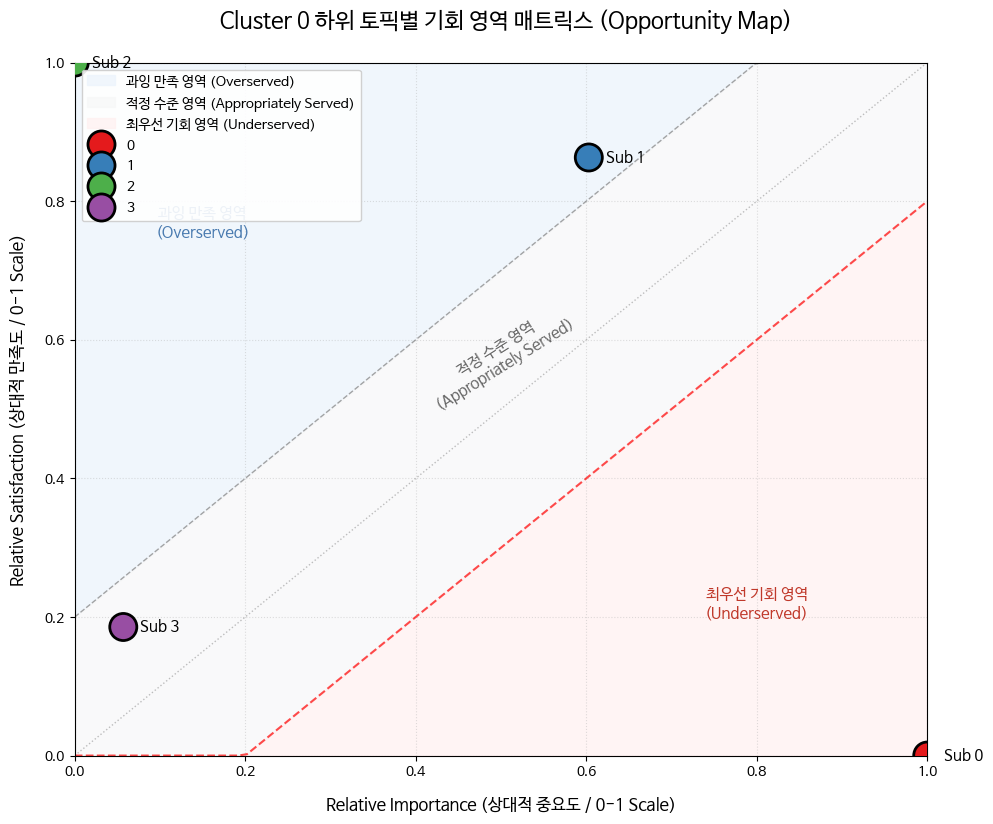

💾 요청하신 대각선 프레임워크 기반의 오퍼튜니티 맵이 구글 드라이브에 저장되었습니다!


In [25]:
# 1. 한글 폰트 설치 및 깨짐 방지 설정
!apt-get -qq -y install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 폰트 지정 객체 생성 (글자 깨짐 방지 마스터 키)
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_title = fm.FontProperties(fname=font_path, size=16, weight='bold')
font_label = fm.FontProperties(fname=font_path, size=12)
font_zone = fm.FontProperties(fname=font_path, size=11, weight='bold')
font_legend = fm.FontProperties(fname=font_path, size=10)

# ==========================================
# 2. Cluster 0 데이터 집계 및 0~1 정규화
# ==========================================
df_c0 = result[result['cluster_k3'] == 0].copy()

stats_c0 = df_c0.groupby('sub_cluster').agg(
    total_count=('sentiment_label', 'count'),
    positive_count=('sentiment_label', lambda x: (x == 'POSITIVE').sum())
).reset_index()

stats_c0['raw_satisfaction'] = stats_c0['positive_count'] / stats_c0['total_count']

# Min-Max Scaling (0~1 스케일 변환)
min_vol, max_vol = stats_c0['total_count'].min(), stats_c0['total_count'].max()
min_sat, max_sat = stats_c0['raw_satisfaction'].min(), stats_c0['raw_satisfaction'].max()

stats_c0['relative_importance'] = (stats_c0['total_count'] - min_vol) / (max_vol - min_vol + 1e-9)
stats_c0['relative_satisfaction'] = (stats_c0['raw_satisfaction'] - min_sat) / (max_sat - min_sat + 1e-9)

# ==========================================
# 3. 앤서니 울윅 스타일의 대각선 오퍼튜니티 맵 시각화
# ==========================================
fig, ax = plt.subplots(figsize=(11, 9))

# 대각선 영역 분할을 위한 수식 매핑 (0에서 1사이 구간)
x_vals = np.linspace(0, 1, 100)
y_upper = np.clip(x_vals + 0.2, 0, 1)
y_lower = np.clip(x_vals - 0.2, 0, 1)

# 대각선 경계선 그리기
ax.plot(x_vals, y_upper, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.plot(x_vals, y_lower, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.plot(x_vals, x_vals, color='gray', linestyle=':', linewidth=1, alpha=0.5) # 정중앙 균형선

# 🎨 오른쪽 이미지 스타일의 3단 영역 음영 채우기
ax.fill_between(x_vals, y_upper, 1, color='#EBF3FC', alpha=0.7, label='과잉 만족 영역 (Overserved)')
ax.fill_between(x_vals, y_lower, y_upper, color='#F7F7F8', alpha=0.7, label='적정 수준 영역 (Appropriately Served)')
ax.fill_between(x_vals, 0, y_lower, color='#FFF0F0', alpha=0.7, label='최우선 기회 영역 (Underserved)')

# 각 영역별 텍스트 라벨 배치 (오른쪽 이미지 감성 그대로)
ax.text(0.15, 0.75, "과잉 만족 영역\n(Overserved)", fontproperties=font_zone, color='#4A7BB0', ha='center')
ax.text(0.50, 0.50, "적정 수준 영역\n(Appropriately Served)", fontproperties=font_zone, color='#666666', ha='center', rotation=32)
ax.text(0.80, 0.20, "최우선 기회 영역\n(Underserved)", fontproperties=font_zone, color='#C0392B', ha='center')

# 데이터 포인트(Sub-clusters) 플롯 생성
sns.scatterplot(
    data=stats_c0,
    x='relative_importance',
    y='relative_satisfaction',
    s=380,
    hue='sub_cluster',
    palette='Set1',
    edgecolor='black',
    linewidth=2,
    zorder=5  # 음영이나 선에 가려지지 않게 최상단 레이어 배치
)

# 각 점 옆에 Sub-cluster 텍스트 표시
for i in range(len(stats_c0)):
    row = stats_c0.iloc[i]
    ax.text(
        row['relative_importance'] + 0.02,
        row['relative_satisfaction'] - 0.005,
        f"Sub {int(row['sub_cluster'])}",
        fontsize=11, weight='bold', zorder=6
    )

# 축 범위 정밀 고정 (0에서 1 스케일)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# 왼쪽 이미지와 동일한 X축, Y축 명칭 설정
ax.set_title('🎯 Cluster 0 하위 토픽별 기회 영역 매트릭스 (Opportunity Map)', fontproperties=font_title, pad=25)
ax.set_xlabel('Relative Importance (상대적 중요도 / 0-1 Scale)', fontproperties=font_label, labelpad=12)
ax.set_ylabel('Relative Satisfaction (상대적 만족도 / 0-1 Scale)', fontproperties=font_label, labelpad=12)

ax.grid(True, linestyle=':', alpha=0.4)
ax.legend(loc='upper left', prop=font_legend, framealpha=0.9)

# 이미지 저장 후 출력
plt.savefig('/content/drive/MyDrive/opportunity_landscape_cluster0.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 요청하신 대각선 프레임워크 기반의 오퍼튜니티 맵이 구글 드라이브에 저장되었습니다!")


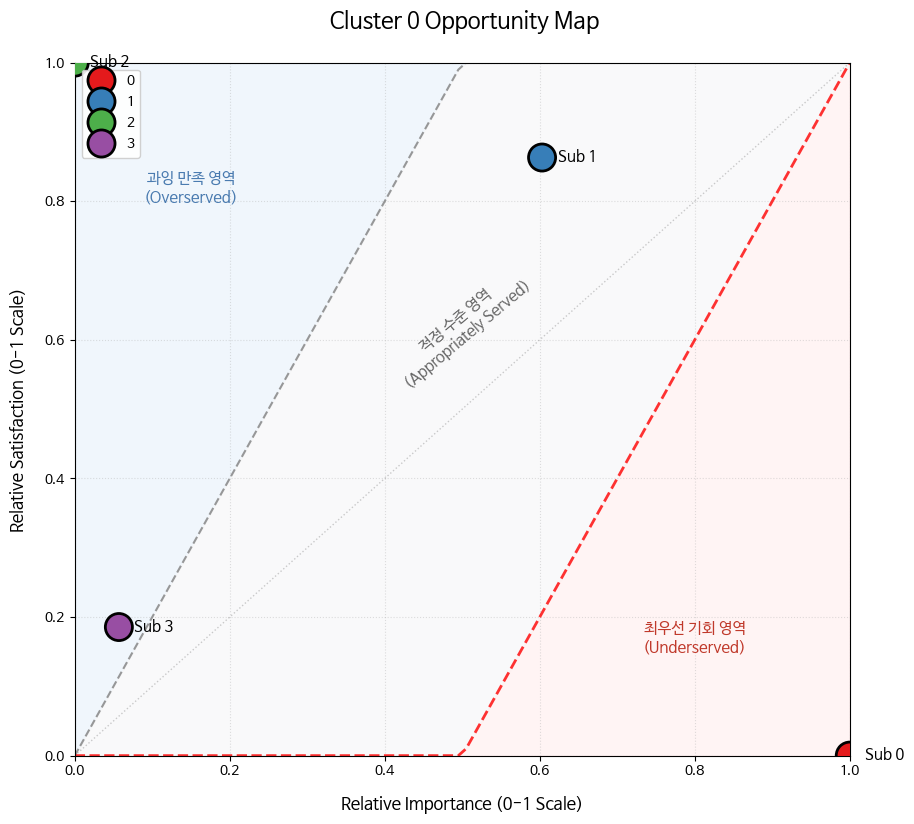

In [28]:
# 1. 한글 폰트 설치 및 깨짐 방지
!apt-get -qq -y install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 폰트 객체 생성
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_title = fm.FontProperties(fname=font_path, size=16, weight='bold')
font_label = fm.FontProperties(fname=font_path, size=12)
font_zone = fm.FontProperties(fname=font_path, size=11, weight='bold')
font_legend = fm.FontProperties(fname=font_path, size=10)

# ==========================================
# 2. Cluster 0 데이터 집계 및 0~1 정규화
# ==========================================
df_c0 = result[result['cluster_k3'] == 0].copy()

stats_c0 = df_c0.groupby('sub_cluster').agg(
    total_count=('sentiment_label', 'count'),
    positive_count=('sentiment_label', lambda x: (x == 'POSITIVE').sum())
).reset_index()

stats_c0['raw_satisfaction'] = stats_c0['positive_count'] / stats_c0['total_count']

# 왼쪽 이미지와 동일한 0-1 Min-Max 스케일링
min_vol, max_vol = stats_c0['total_count'].min(), stats_c0['total_count'].max()
min_sat, max_sat = stats_c0['raw_satisfaction'].min(), stats_c0['raw_satisfaction'].max()

stats_c0['relative_importance'] = (stats_c0['total_count'] - min_vol) / (max_vol - min_vol + 1e-9)
stats_c0['relative_satisfaction'] = (stats_c0['raw_satisfaction'] - min_sat) / (max_sat - min_sat + 1e-9)

# ==========================================
# 3. 진짜 앤서니 울윅 대각선 매트릭스 시각화
# ==========================================
fig, ax = plt.subplots(figsize=(10, 9))

# 0~1 스케일 구간 정의
x_vals = np.linspace(0, 1, 100)

# 🔥 핵심 수정: 오른쪽 이미지의 진짜 울윅 대각선 수식 적용 (기울기 2)
# 과잉만족 경계: Sat = 2 * Imp (최대값 1로 제한)
y_upper = np.minimum(2 * x_vals, 1)
# 최우선기회 경계: Sat = 2 * Imp - 1 (최소값 0으로 제한)
y_lower = np.maximum(2 * x_vals - 1, 0)

# 경계 대각선 그리기 (오른쪽 그림과 동일한 각도)
ax.plot(x_vals, y_upper, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)
ax.plot(x_vals, y_lower, color='red', linestyle='--', linewidth=2, alpha=0.8)
ax.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=1, alpha=0.4) # 1:1 균형선

# 🎨 오른쪽 그림의 부채꼴 모양 영역별 음영 채우기
ax.fill_between(x_vals, y_upper, 1, color='#EBF3FC', alpha=0.7) # 과잉 만족 (상단 무대)
ax.fill_between(x_vals, y_lower, y_upper, color='#F7F7F8', alpha=0.7) # 적정 수준 (가운데 끼인 무대)
ax.fill_between(x_vals, 0, y_lower, color='#FFF0F0', alpha=0.7) # 최우선 기회 (하단 무대)

# 영역별 텍스트 배치 위치 수정 (오른쪽 그림 레이아웃 준수)
ax.text(0.15, 0.80, "과잉 만족 영역\n(Overserved)", fontproperties=font_zone, color='#4A7BB0', ha='center')
ax.text(0.50, 0.53, "적정 수준 영역\n(Appropriately Served)", fontproperties=font_zone, color='#666666', ha='center', rotation=40)
ax.text(0.80, 0.15, "최우선 기회 영역\n(Underserved)", fontproperties=font_zone, color='#C0392B', ha='center')

# 데이터 포인트(Sub-clusters) 플롯 (최상단 레이어)
sns.scatterplot(
    data=stats_c0,
    x='relative_importance',
    y='relative_satisfaction',
    s=380,
    hue='sub_cluster',
    palette='Set1',
    edgecolor='black',
    linewidth=2,
    zorder=5
)

# 각 점 옆에 Sub-cluster 넘버링 라벨링
for i in range(len(stats_c0)):
    row = stats_c0.iloc[i]
    ax.text(
        row['relative_importance'] + 0.02,
        row['relative_satisfaction'] - 0.005,
        f"Sub {int(row['sub_cluster'])}",
        fontsize=11, weight='bold', zorder=6
    )

# 축 범위 고정 (왼쪽 이미지와 동일하게 0~1 정밀 제어)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# 왼쪽 이미지와 100% 일치하는 축 레이블 명칭
ax.set_title(' Cluster 0 Opportunity Map', fontproperties=font_title, pad=25)
ax.set_xlabel('Relative Importance (0-1 Scale)', fontproperties=font_label, labelpad=12)
ax.set_ylabel('Relative Satisfaction (0-1 Scale)', fontproperties=font_label, labelpad=12)

ax.grid(True, linestyle=':', alpha=0.4)
ax.legend(loc='upper left', prop=font_legend, framealpha=0.9)

# 드라이브 저장 및 출력
plt.savefig('/content/drive/MyDrive/opportunity_landscape_cluster0_final')


💡 [데이터 실시간 검증 로그]
- 원본 데이터(result) 총 행 개수: 43565개
- 현재 cluster_k3에 들어있는 고유값들: [0 2] (타입: int32)
- 0, 1, 2 클러스터 필터링 후 남은 행 개수: 43565개
- sub_cluster 컬럼의 결측치(NaN) 개수: 0개
- 최종 매트릭스에 찍힐 점(하위 토픽)의 총 개수: 9개

📊 [집계 완료된 데이터 매핑 테이블]
   cluster_k3  sub_cluster  total_count  positive_count
0           0            0         8178            1671
1           0            1         6553            2177
2           0            2         4085            1440
3           0            3         4318            1001
4           2            0         5129            2060
5           2            1         5787            2104
6           2            2         3807            1734
7           2            3         5495            3319
8           2            4          213               0


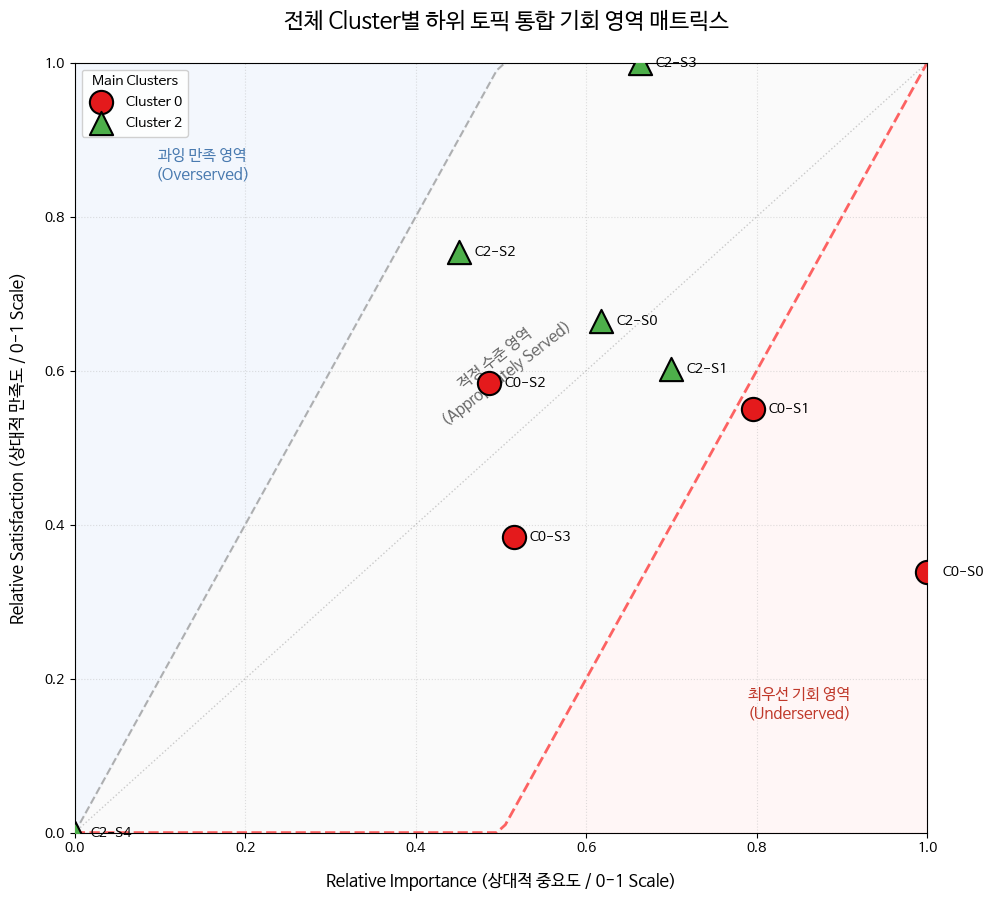

In [30]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. 한글 폰트 설치 및 지정
!apt-get -qq -y install fonts-nanum > /dev/null
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_title = fm.FontProperties(fname=font_path, size=16, weight='bold')
font_label = fm.FontProperties(fname=font_path, size=12)
font_zone = fm.FontProperties(fname=font_path, size=11, weight='bold')
font_legend = fm.FontProperties(fname=font_path, size=10)

# ==========================================
# 🔍 [안전 장치 및 디버깅존] 데이터 실종 원인 추적
# ==========================================
print("💡 [데이터 실시간 검증 로그]")
print(f"- 원본 데이터(result) 총 행 개수: {len(result)}개")
print(f"- 현재 cluster_k3에 들어있는 고유값들: {result['cluster_k3'].unique()} (타입: {result['cluster_k3'].dtype})")

# 안전한 데이터 처리를 위해 복사본 생성
df_all = result.copy()

# 데이터 타입 불일치 해결: 무조건 문자열로 바꾼 뒤 공백 제거하고 비교
df_all['cluster_k3_tmp'] = df_all['cluster_k3'].astype(str).str.strip().str.replace('.0', '', regex=False)
df_all = df_all[df_all['cluster_k3_tmp'].isin(['0', '1', '2'])].copy()
df_all['cluster_k3'] = df_all['cluster_k3_tmp'].astype(int)

print(f"- 0, 1, 2 클러스터 필터링 후 남은 행 개수: {len(df_all)}개")

# sub_cluster 컬럼이 비어있거나 없는 경우 예외 처리
if 'sub_cluster' not in df_all.columns:
    print("🚨 경고: 데이터프레임에 'sub_cluster' 컬럼이 아예 없습니다!")
    df_all['sub_cluster'] = 0  # 임시 강제 지정
else:
    nan_count = df_all['sub_cluster'].isna().sum()
    print(f"- sub_cluster 컬럼의 결측치(NaN) 개수: {nan_count}개")
    # NaN이 있으면 groupby할 때 데이터가 삭제되므로 임시로 미분류(-1) 처리
    df_all['sub_cluster'] = df_all['sub_cluster'].fillna(-1)

# 데이터 집계 진행
stats_all = df_all.groupby(['cluster_k3', 'sub_cluster']).agg(
    total_count=('sentiment_label', 'count'),
    positive_count=('sentiment_label', lambda x: (x == 'POSITIVE').sum())
).reset_index()

print(f"- 최종 매트릭스에 찍힐 점(하위 토픽)의 총 개수: {len(stats_all)}개")
print("\n📊 [집계 완료된 데이터 매핑 테이블]")
print(stats_all)
print("="*60)

# ==========================================
# 2. 데이터가 확인되었을 때만 시각화 수행
# ==========================================
if len(stats_all) == 0:
    print("❌ [중단] 집계된 데이터가 한 개도 없습니다. 위 검증 로그에서 데이터 개수가 0이 된 구간을 확인하세요.")
else:
    # 만족도 계산 및 글로벌 0~1 스케일링
    stats_all['raw_satisfaction'] = stats_all['positive_count'] / stats_all['total_count']

    min_vol, max_vol = stats_all['total_count'].min(), stats_all['total_count'].max()
    min_sat, max_sat = stats_all['raw_satisfaction'].min(), stats_all['raw_satisfaction'].max()

    # 데이터가 1개뿐이거나 값이 모두 같아 분모가 0이 되는 현상 방지
    denom_vol = max_vol - min_vol if max_vol != min_vol else 1
    denom_sat = max_sat - min_sat if max_sat != min_sat else 1

    stats_all['relative_importance'] = (stats_all['total_count'] - min_vol) / denom_vol
    stats_all['relative_satisfaction'] = (stats_all['raw_satisfaction'] - min_sat) / denom_sat

    # 도화지 그리기
    fig, ax = plt.subplots(figsize=(11, 10))

    # 진짜 앤서니 울윅 대각선 수식 적용 (기울기 2)
    x_vals = np.linspace(0, 1, 100)
    y_upper = np.minimum(2 * x_vals, 1)
    y_lower = np.maximum(2 * x_vals - 1, 0)

    # 경계 가이드 라인
    ax.plot(x_vals, y_upper, color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.plot(x_vals, y_lower, color='red', linestyle='--', linewidth=2, alpha=0.6)
    ax.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=1, alpha=0.4)

    # 3단 영역 배경 음영 채우기
    ax.fill_between(x_vals, y_upper, 1, color='#EBF3FC', alpha=0.6)
    ax.fill_between(x_vals, y_lower, y_upper, color='#F7F7F8', alpha=0.6)
    ax.fill_between(x_vals, 0, y_lower, color='#FFF0F0', alpha=0.6)

    # 영역 대표 글자 배치
    ax.text(0.15, 0.85, "과잉 만족 영역\n(Overserved)", fontproperties=font_zone, color='#4A7BB0', ha='center')
    ax.text(0.50, 0.53, "적정 수준 영역\n(Appropriately Served)", fontproperties=font_zone, color='#666666', ha='center', rotation=38)
    ax.text(0.85, 0.15, "최우선 기회 영역\n(Underserved)", fontproperties=font_zone, color='#C0392B', ha='center')

    # 메인 클러스터별 색상 및 마커 형태 정의 (0=빨간원, 1=파란네모, 2=초록세모)
    cluster_colors = {0: '#E41A1C', 1: '#377EB8', 2: '#4DAF4A'}
    cluster_markers = {0: 'o', 1: 's', 2: '^'}

    # 각 클러스터별로 루프를 돌며 점 찍기
    for c_num in [0, 1, 2]:
        c_data = stats_all[stats_all['cluster_k3'] == c_num]
        if len(c_data) > 0:
            ax.scatter(
                c_data['relative_importance'],
                c_data['relative_satisfaction'],
                s=280,
                color=cluster_colors[c_num],
                marker=cluster_markers[c_num],
                edgecolor='black',
                linewidth=1.5,
                label=f'Cluster {c_num}',
                zorder=5
            )

    # 점 옆에 텍스트 라벨 매핑 (예: C0-S1)
    for i in range(len(stats_all)):
        row = stats_all.iloc[i]
        sub_num = int(row['sub_cluster'])
        sub_label = f"S{sub_num}" if sub_num != -1 else "미분류"
        ax.text(
            row['relative_importance'] + 0.018,
            row['relative_satisfaction'] - 0.005,
            f"C{int(row['cluster_k3'])}-{sub_label}",
            fontsize=10, weight='bold', zorder=6
        )

    # 축 설정 고정
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title('🎯 전체 Cluster별 하위 토픽 통합 기회 영역 매트릭스', fontproperties=font_title, pad=25)
    ax.set_xlabel('Relative Importance (상대적 중요도 / 0-1 Scale)', fontproperties=font_label, labelpad=12)
    ax.set_ylabel('Relative Satisfaction (상대적 만족도 / 0-1 Scale)', fontproperties=font_label, labelpad=12)
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.legend(loc='upper left', prop=font_legend, framealpha=0.9, title="Main Clusters")

    plt.savefig('/content/drive/MyDrive/opportunity_landscape_all_clusters_fixed.png', dpi=300, bbox_inches='tight')
    plt.show()